# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# ==========================================
# 1. LIBRARY UNTUK MANIPULASI & ANALISIS DATA
# ==========================================
import pandas as pd
import numpy as np

# ==========================================
# 2. LIBRARY UNTUK VISUALISASI DATA (EDA)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ==========================================
# 3. LIBRARY UNTUK TEXT PREPROCESSING (NLP)
# ==========================================
import re
import string
# Catatan: Jika nanti butuh Sastrawi untuk stemming Bahasa Indonesia,
# Anda perlu install dulu di cell terpisah pakai: !pip install Sastrawi

# ==========================================
# 4. LIBRARY MACHINE LEARNING & EVALUASI (Scikit-Learn)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==========================================
# 5. LIBRARY DEEP LEARNING (TensorFlow / Keras)
# ==========================================
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

# Mengatur agar visualisasi matplotlib langsung muncul di notebook
%matplotlib inline

print("Pustaka berhasil diimpor! Siap melangkah ke tahap berikutnya.")

Pustaka berhasil diimpor! Siap melangkah ke tahap berikutnya.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# =================================================================
# TAHAP 3: MEMUAT DATASET (DATA LOADING)
# =================================================================

# 1. Memuat dataset utama (Kumpulan Tweet dan Label Hate Speech)
# Kita gunakan encoding='latin-1' atau 'utf-8' untuk mengantisipasi karakter khusus media sosial
df_data = pd.read_csv('data.csv', encoding='latin-1')

# 2. Memuat kamus alay untuk normalisasi kata (tanpa header di file aslinya)
df_kamusalay = pd.read_csv('new_kamusalay.csv', encoding='latin-1', header=None, names=['kata_alay', 'kata_baku'])

# 3. Memuat daftar kata kasar (abusive words)
df_abusive = pd.read_csv('abusive.csv', encoding='latin-1')

# =================================================================
# MENGECEK STRUKTUR DATA
# =================================================================

print("==================================================")
print("1. MENAMPILKAN 5 BARIS PERTAMA DATASET UTAMA (data.csv)")
print("==================================================")
display(df_data.head())

print("\n==================================================")
print("2. INFORMASI STRUKTUR & TIPE DATA (df_data.info())")
print("==================================================")
df_data.info()

print("\n==================================================")
print("3. DIMENSI DATASET UTAMA")
print("==================================================")
print(f"Jumlah baris (Tweet): {df_data.shape[0]}")
print(f"Jumlah kolom (Fitur/Label): {df_data.shape[1]}")

1. MENAMPILKAN 5 BARIS PERTAMA DATASET UTAMA (data.csv)


,Tweet,HS,Abusive,HS_Individual,HS_Group,HS_Religion,HS_Race,HS_Physical,HS_Gender,HS_Other,HS_Weak,HS_Moderate,HS_Strong
0,- disaat semua cowok berusaha melacak perhatia...,1,1,1,0,0,0,0,0,1,1,0,0
1,RT USER: USER siapa yang telat ngasih tau elu?...,0,1,0,0,0,0,0,0,0,0,0,0
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",0,0,0,0,0,0,0,0,0,0,0,0
3,USER USER AKU ITU AKU\n\nKU TAU MATAMU SIPIT T...,0,0,0,0,0,0,0,0,0,0,0,0
4,USER USER Kaum cebong kapir udah keliatan dong...,1,1,0,1,1,0,0,0,0,0,1,0



2. INFORMASI STRUKTUR & TIPE DATA (df_data.info())
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13169 entries, 0 to 13168
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Tweet          13169 non-null  object
 1   HS             13169 non-null  int64 
 2   Abusive        13169 non-null  int64 
 3   HS_Individual  13169 non-null  int64 
 4   HS_Group       13169 non-null  int64 
 5   HS_Religion    13169 non-null  int64 
 6   HS_Race        13169 non-null  int64 
 7   HS_Physical    13169 non-null  int64 
 8   HS_Gender      13169 non-null  int64 
 9   HS_Other       13169 non-null  int64 
 10  HS_Weak        13169 non-null  int64 
 11  HS_Moderate    13169 non-null  int64 
 12  HS_Strong      13169 non-null  int64 
dtypes: int64(12), object(1)
memory usage: 1.3+ MB

3. DIMENSI DATASET UTAMA
Jumlah baris (Tweet): 13169
Jumlah kolom (Fitur/Label): 13


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

/tmp/ipykernel_20905/4087050062.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HS', data=df_data, palette='Set2')
/tmp/ipykernel_20905/4087050062.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Abusive', data=df_data, palette='Pastel1')


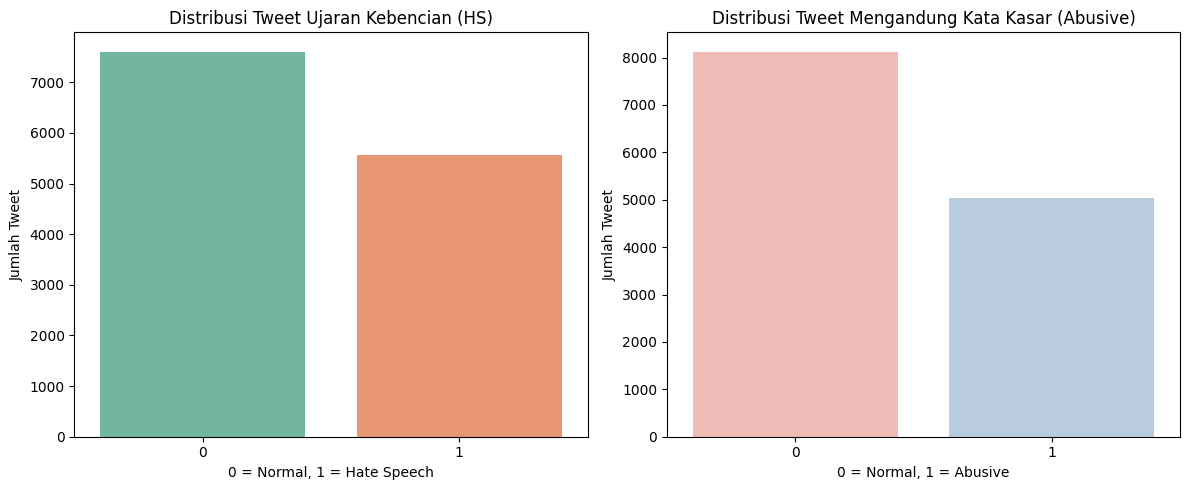

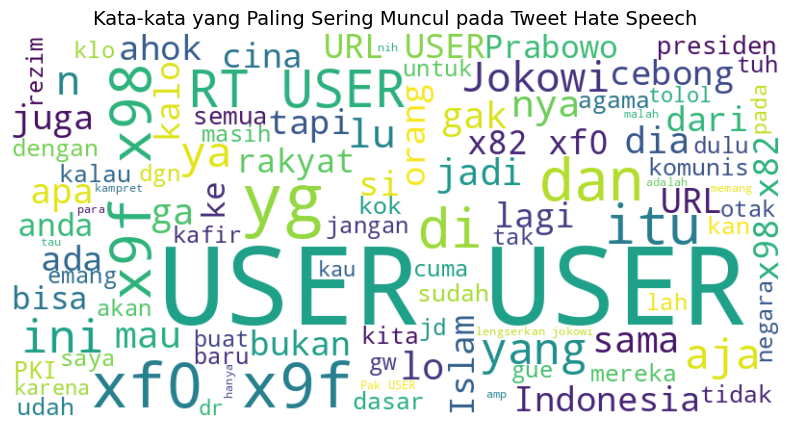

In [3]:
# =================================================================
# TAHAP 4: EXPLORATORY DATA ANALYSIS (EDA)
# =================================================================

# 1. Distribusi Label Utama (Hate Speech vs Non-Hate Speech)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='HS', data=df_data, palette='Set2')
plt.title('Distribusi Tweet Ujaran Kebencian (HS)')
plt.xlabel('0 = Normal, 1 = Hate Speech')
plt.ylabel('Jumlah Tweet')

# 2. Distribusi Label Abusive (Kata-kata Kasar)
plt.subplot(1, 2, 2)
sns.countplot(x='Abusive', data=df_data, palette='Pastel1')
plt.title('Distribusi Tweet Mengandung Kata Kasar (Abusive)')
plt.xlabel('0 = Normal, 1 = Abusive')
plt.ylabel('Jumlah Tweet')

plt.tight_layout()
plt.show()

# =================================================================
# 3. VISUALISASI KATA KUNCI MENGGUNAKAN WORDCLOUD
# =================================================================

# Menggabungkan semua tweet yang masuk kategori Hate Speech (HS == 1)
hate_speech_tweets = " ".join(df_data[df_data['HS'] == 1]['Tweet'])

# Membuat grafik WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(hate_speech_tweets)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Kata-kata yang Paling Sering Muncul pada Tweet Hate Speech', fontsize=14)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# =================================================================
# TAHAP 5: DATA PREPROCESSING (KHUSUS DATA TEKS NLP)
# =================================================================

# --- 1. MENANGANI DATA KOSONG (MISSING VALUES) & DUPLIKAT ---
print("=== Sebelum Preprocessing ===")
print(f"Jumlah baris awal: {len(df_data)}")

# Menghapus data yang kolom teksnya kosong
df_data = df_data.dropna(subset=['Tweet'])

# Menghapus data tweet yang duplikat
df_data = df_data.drop_duplicates(subset=['Tweet'])

print(f"Jumlah baris setelah hapus kosong & duplikat: {len(df_data)}\n")


# --- 2. PERSIAPAN KAMUS ALAY UNTUK NORMALISASI ---
# Mengubah DataFrame kamus alay menjadi dictionary Python agar proses pencarian cepat
alay_dict = dict(zip(df_kamusalay['kata_alay'], df_kamusalay['kata_baku']))


# --- 3. MEMBUAT FUNGSI TEXT CLEANSING (TEXT PREPROCESSING) ---
def clean_text(text):
    # a. Case Folding: Mengubah teks menjadi huruf kecil
    text = text.lower()

    # b. Menghapus URL / Link Website
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # c. Menghapus Mention Twitter (@user) dan Hashtag (#tag)
    text = re.sub(r'@\S+', '', text)
    text = re.sub(r'#\S+', '', text)

    # d. Menghapus karakter non-ASCII (seperti emoji, cina, arab, dll)
    text = text.encode('ascii', 'ignore').decode('utf-8')

    # e. Menghapus tanda baca dan angka
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)

    # f. Menghapus spasi berlebih
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)

    # g. Normalisasi Kata Alay / Singkatan menjadi Kata Baku
    words = text.split()
    normalized_words = [alay_dict[word] if word in alay_dict else word for words in [words] for word in words]
    text = " ".join(normalized_words)

    return text

# --- 4. MENJALANKAN PROSES PEMBERSIHAN ---
print("Sedang memproses pembersihan teks tweet... Mohon tunggu sebentar.")

# Membuat kolom baru bernama 'Tweet_Clean' untuk menyimpan hasil bersihnya
df_data['Tweet_Clean'] = df_data['Tweet'].apply(clean_text)

print("Proses Preprocessing Selesai!\n")


# --- 5. MENAMPILKAN PERBANDINGAN SEBELUM & SESUDAH ---
print("=== PERBANDINGAN HASIL PREPROCESSING ===")
for i in range(3):
    print(f"\n[Tweet Mentah {i+1}]: {df_data['Tweet'].iloc[i]}")
    print(f"[Tweet Bersih {i+1}]: {df_data['Tweet_Clean'].iloc[i]}")

=== Sebelum Preprocessing ===
Jumlah baris awal: 13169
Jumlah baris setelah hapus kosong & duplikat: 13023

Sedang memproses pembersihan teks tweet... Mohon tunggu sebentar.
Proses Preprocessing Selesai!

=== PERBANDINGAN HASIL PREPROCESSING ===

[Tweet Mentah 1]: - disaat semua cowok berusaha melacak perhatian gue. loe lantas remehkan perhatian yg gue kasih khusus ke elo. basic elo cowok bego ! ! !'
[Tweet Bersih 1]: di saat semua cowok berusaha melacak perhatian gue kamu lantas remehkan perhatian yang gue kasih khusus ke kamu basic kamu cowok bego

[Tweet Mentah 2]: RT USER: USER siapa yang telat ngasih tau elu?edan sarap gue bergaul dengan cigax jifla calis sama siapa noh licew juga'
[Tweet Bersih 2]: rt pengguna pengguna siapa yang telat memberi tau eluedan sarap gue bergaul dengan cigax jifla calis sama siapa itu licew juga

[Tweet Mentah 3]: 41. Kadang aku berfikir, kenapa aku tetap percaya pada Tuhan padahal aku selalu jatuh berkali-kali. Kadang aku merasa Tuhan itu ninggalkan a

In [5]:
# Menyimpan dataset yang sudah bersih ke dalam file CSV baru
df_data.to_csv('namadataset_preprocessing.csv', index=False)

print("File 'namadataset_preprocessing.csv' berhasil dibuat! Silakan unduh file ini dari panel kiri Colab.")

File 'namadataset_preprocessing.csv' berhasil dibuat! Silakan unduh file ini dari panel kiri Colab.
